# Análisis descriptivo de datos con Python (Parte 2)
# Análisis de dispersión y normalidad — Base de datos titanic

Este notebook analiza la variable `age` usando medidas de dispersión y evalúa si está normalmente distribuida. También incluye visualizaciones y análisis por grupo.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from scipy.stats import shapiro, skew, kurtosis, probplot


# Cargar el dataset limpio
df = pd.read_csv("titanic.csv")
df.head()

,passenger_class,name,age,embarked,home_destination,sex,survive
0,1st,"Allen,MissElisabethWalton",29.0000,Southampton,"StLouis,MO",female,yes
1,1st,"Allison,MissHelenLoraine",2.0000,Southampton,"Montreal,PQ/Chesterville,ON",female,no
2,1st,"Allison,MrHudsonJoshuaCreighton",30.0000,Southampton,"Montreal,PQ/Chesterville,ON",male,no
3,1st,"Allison,MrsHudsonJ.C.(BessieWaldoDaniels)",25.0000,Southampton,"Montreal,PQ/Chesterville,ON",female,no
4,1st,"Allison,MasterHudsonTrevor",0.9167,Southampton,"Montreal,PQ/Chesterville,ON",male,yes


## Parte 1: Medidas de Dispersión para `age`

In [2]:
# Eliminar valores nulos de 'age'
edad = df['age'].dropna()

print(f"Rango: {edad.max() - edad.min():.2f}")
print(f"Varianza: {edad.var():.2f}")
print(f"Desviación estándar: {edad.std():.2f}")
print(f"Coeficiente de variación: {edad.std() / edad.mean():.2f}")

Rango: 70.83
Varianza: 217.49
Desviación estándar: 14.75
Coeficiente de variación: 0.47


## Parte 2: Dispersión por Grupo

In [3]:
df.groupby("passenger_class")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
passenger_class,,,,,,,,
1st,226.0,39.667773,14.930440,0.9167,28.0,39.5,50.0,71.0
2nd,212.0,28.300314,13.007643,0.8333,21.0,28.0,35.0,71.0
3rd,195.0,24.519658,11.330594,0.1667,18.0,24.0,32.0,65.0


In [4]:
df.groupby("sex")["age"].std()

sex
female    14.868476
male      14.677484
Name: age, dtype: float64

## Nota: ¿Por qué usamos `dropna()` para `age`?

En algunas versiones del dataset de Titanic, los valores faltantes de la columna `age` se rellenan con la mediana (por ejemplo, 30 años).

Esto puede ser útil para modelos predictivos, pero **no es adecuado** cuando queremos analizar:

- La **distribución real** de los datos.
- La **desviación estándar** y otras medidas de dispersión.
- La **normalidad** de los datos (como en pruebas de Shapiro-Wilk).

> Por eso, en este análisis usamos `edad = df['age'].dropna()` para trabajar sólo con los valores originales y evitar sesgos introducidos por imputación artificial.


## Parte 3: Visualización de la Distribución de Edad

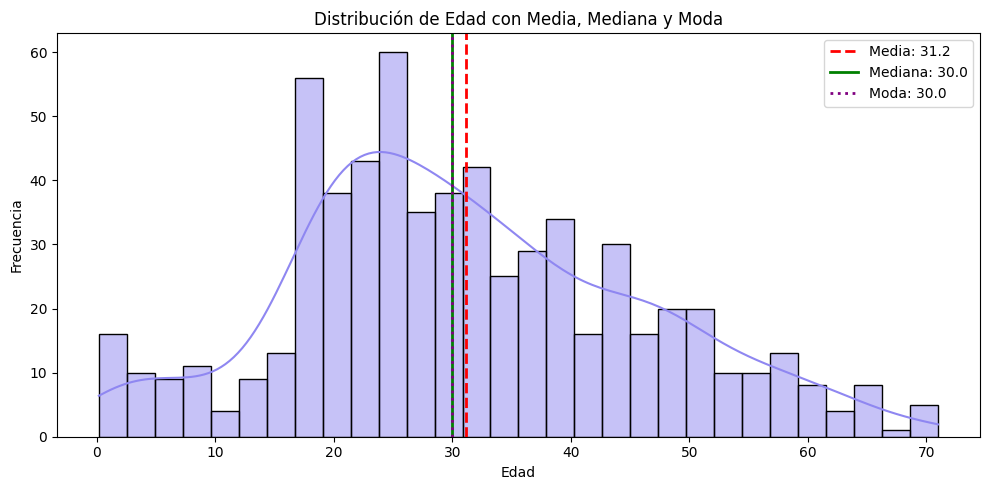

In [5]:
# Calcular medidas de localización
media = df['age'].mean()
mediana = df['age'].median()
moda = df['age'].mode()[0]

# Crear el histograma con líneas para media, mediana y moda
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=30, kde=True, color='#8F87F1')

plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.1f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.1f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.1f}')

plt.title('Distribución de Edad con Media, Mediana y Moda')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

El Q-Q plot (Quantile-Quantile Plot) es una herramienta gráfica que nos ayuda a comparar la distribución de nuestros datos con una distribución teórica, comúnmente la normal. Si los puntos del gráfico siguen aproximadamente una línea recta, podemos decir que los datos siguen una distribución normal. En este caso, analizamos la variable age, y cualquier desviación sistemática de la línea (como una curva o extremos alejados) indica que los datos podrían no ser normales. Esta gráfica complementa el histograma y nos da una forma visual más precisa de evaluar la normalidad estadística.

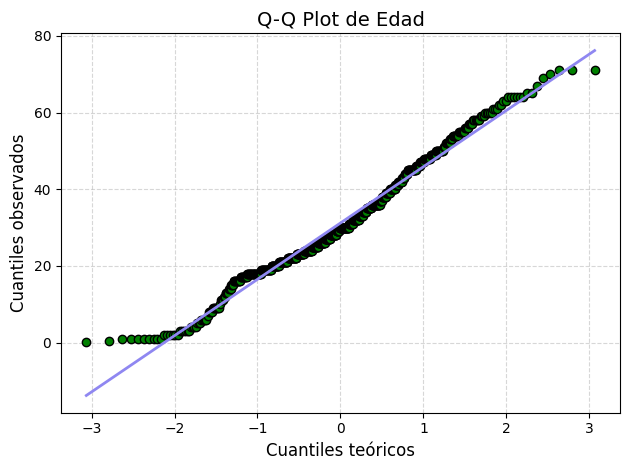

In [7]:
ax = plt.gca() 
# Q-Q Plot
res = scipy.stats.probplot(df['age'].dropna(), dist="norm", plot=ax)

# Personalización
ax.get_lines()[1].set_color('#8F87F1')   # línea de referencia
ax.get_lines()[1].set_linewidth(2)
ax.get_lines()[0].set_markerfacecolor('green')
ax.get_lines()[0].set_markeredgecolor('black')

plt.title("Q-Q Plot de Edad", fontsize=14)
plt.xlabel("Cuantiles teóricos", fontsize=12)
plt.ylabel("Cuantiles observados", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

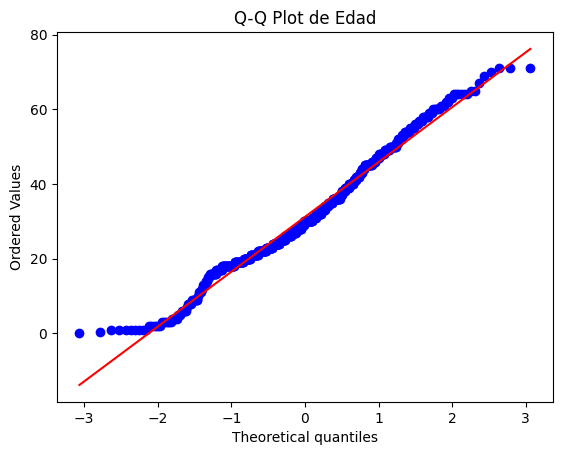

In [20]:
probplot(edad, dist="norm", plot=plt)
plt.title("Q-Q Plot de Edad")
plt.show()

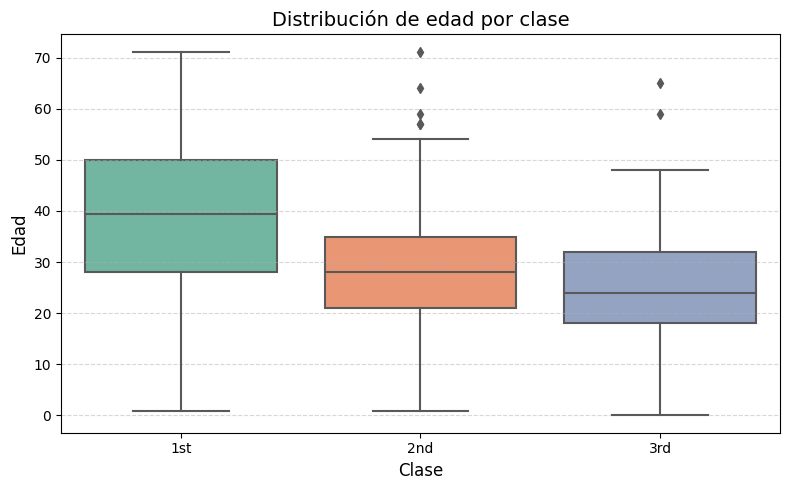

In [9]:
# Crear boxplot con colores personalizados por sexo
plt.figure(figsize=(8, 5))
sns.boxplot(x='passenger_class', y='age', data=df, palette='Set2')

plt.title("Distribución de edad por clase", fontsize=14)
plt.xlabel("Clase", fontsize=12)
plt.ylabel("Edad", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [11]:
df.query("age > 55 and passenger_class == '2nd'")

,passenger_class,name,age,embarked,home_destination,sex,survive
328,2nd,"Ashby,MrJohn",57.0,Southampton,"WestHoboken,NJ",male,no
487,2nd,"Mack,MrsMary",57.0,Southampton,"Southampton/NewYork,NY",female,no
505,2nd,"Mitchell,MrHenryMichael",71.0,Southampton,"Guernsey/Montclair,NJand/orToledo,Ohio",male,no
509,2nd,"Myles,MrThomasFrancis",64.0,Queenstown,"Cambridge,MA",male,no
556,2nd,"Sjostedt,MrErnstAdolf",59.0,Southampton,"SaultStMarie,ON",male,no


In [12]:
df.query("age > 55 and passenger_class == '3rd'")

,passenger_class,name,age,embarked,home_destination,sex,survive
739,3rd,"Coxon,MrDaniel",59.0,Southampton,"Merrill,WI",male,no
772,3rd,"Dewan,MrFrank",65.0,Queenstown,NaN,male,no


In [13]:
outliers = [328,487,505,509,556,739,772]
df.drop(index=outliers,inplace=True)

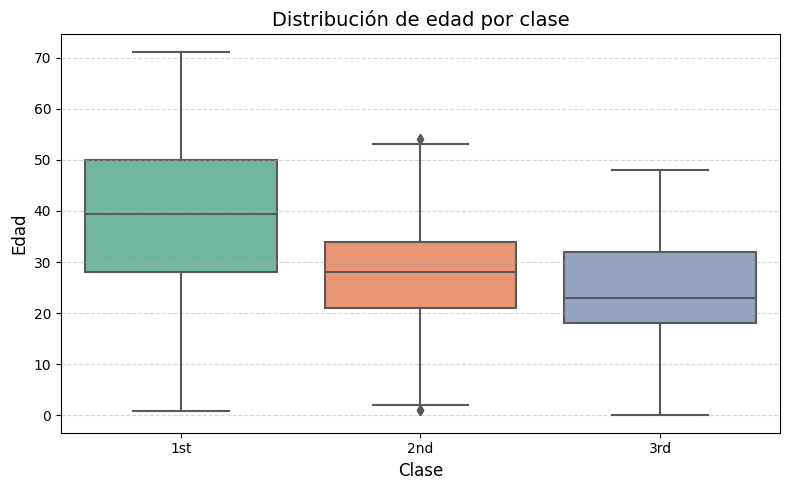

In [19]:
# Crear boxplot con colores personalizados por sexo
plt.figure(figsize=(8, 5))
sns.boxplot(x='passenger_class', y='age', data=df, palette='Set2')

plt.title("Distribución de edad por clase", fontsize=14)
plt.xlabel("Clase", fontsize=12)
plt.ylabel("Edad", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [17]:
df.query("age < 1 and passenger_class == '2nd'")

,passenger_class,name,age,embarked,home_destination,sex,survive
358,2nd,"Caldwell,MasterAldenGates",0.8333,Southampton,"Bangkok,Thailand/Roseville,IL",male,yes
544,2nd,"Richards,MasterGeorgeSidney",0.8333,Southampton,"Cornwall/Akron,OH",male,yes


In [18]:
outliers = [358,544]
df.drop(index=outliers,inplace=True)

## Parte 4: Pruebas de Normalidad

La prueba de Shapiro-Wilk es un test estadístico diseñado para evaluar si un conjunto de datos sigue una distribución normal. Esta prueba calcula un estadístico (W) y un p-valor. Si el p-valor es menor que 0.05, se rechaza la hipótesis nula de que los datos provienen de una distribución normal, lo que indica que los datos no son normales. En cambio, si el p-valor es mayor o igual a 0.05, no se rechaza la normalidad, lo que significa que los datos podrían considerarse normalmente distribuidos. Es importante tener en cuenta que esta prueba es sensible al tamaño de la muestra y a la presencia de valores atípicos.

In [21]:
stat, p = shapiro(edad)
print(f"Estadístico Shapiro-Wilk: {stat:.3f}")
print(f"p-valor: {p:.3f}")
if p < 0.05:
    print("Los datos NO siguen una distribución normal.")
else:
    print("No se rechaza la normalidad (distribución normal posible).")

Estadístico Shapiro-Wilk: 0.983
p-valor: 0.000
Los datos NO siguen una distribución normal.


Hipótesis nula **$H_0$**: Los datos no son normales.

Si **p < 0.05** Se acepta la hipótesis nula y decimos que los datos no son normales.
En otro caso se rechaza la hipótesis nula y decimos que la distribución es normal.

Asimetría (skew) y curtosis son momentos estadísticos que describen la forma de una distribución — más allá de su centro y su dispersión.

Asimetría mide la simetría de los datos respecto a la media. Un valor cercano a 0 indica equilibrio; un valor positivo significa que la cola derecha es más larga (hay más valores grandes alejados del centro), mientras que un valor negativo refleja una cola izquierda más pronunciada.

Curtosis cuantifica el peso de las colas y la punta de la distribución. Para una distribución normal, la curtosis (exceso) es 0. Un valor positivo (> 0) señala colas más pesadas y datos más concentrados en el centro (distribución “picuda”, leptocúrtica); un valor negativo (< 0) sugiere colas más ligeras y una forma más achatada (platicúrtica).
Estos dos indicadores complementan al histograma y al Q-Q plot: ayudan a detectar sesgos o colas extremas que pueden invalidar suposiciones de normalidad y, por tanto, influir en la elección de pruebas estadísticas y medidas de dispersión apropiadas.

In [22]:
print(f"Asimetría (skew): {skew(edad):.3f}")
print(f"Curtosis: {kurtosis(edad):.3f}")

Asimetría (skew): 0.302
Curtosis: -0.230


## Conclusión
- Se analizaron medidas de dispersión para `age`.
- Se evaluó su distribución usando visualización y pruebas estadísticas.
- La desviación estándar es útil solo si los datos son normales; si no, usar IQR o MAD.